In [10]:
import os, random, warnings, csv, json as _json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [11]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [12]:
def seed_everything(seed: int = 7):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(7)
print('Seed = 7')

Seed = 7


In [ ]:
# MAIN CONFIG 

# Paths
TRAIN_DATA_ROOT = os.path.expanduser('~/Desktop/george/rocks_spectral_224')
TEST_DATA_ROOT   = os.path.expanduser('~/for_test_data_spectral_224')
RESULTS_DIR     = 'results_rock_classifier_combined'

# Model architecture 
ARCH             = 'resnet18'

# Training flags
MAX_PER_CLASS    = None   
USE_STRONG_AUG   = True   
FREEZE_BACKBONE  = False 
EPOCHS           = 20
LR               = 1e-4
WEIGHT_DECAY     = 1e-4
BATCH_SIZE       = 64
TEST_SPLIT       = 0.30   

# OOD calibration
OOD_FPR = 0.05

# Classes 
CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
CLASS_COLORS = ['#4e79a7', '#f28e2b', '#59a14f']
OOD_COLOR    = '#e15759'

# Expected ground-truth class for each new rock folder.
EXPECTED_CLASS = {
    'Dunite-Ecologite_2Rocks_1-83Hz'               : 'Unknown',
    'Gneis_1-83Hz'                                  : 'S10Granite',
    'Granite_3SamplesPhilipp_1-83Hz_1'              : 'S10Granite',
    'Granite_3SamplesPhilipp_1-83Hz_2'              : 'S10Granite',
    'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz' : 'Leitendorf_Limestone',
    'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz' : 'Leitendorf_Limestone',
    'Limestone_Rax_1-83Hz_1'                        : 'Leitendorf_Limestone',
    'Limestone_Rax_1-83Hz_2'                        : 'Leitendorf_Limestone',
    'SandstoneNew_1-83Hz'                           : 'Holstein_Sandstone',
}

# Result sub-folders
DIR_TRAIN = os.path.join(RESULTS_DIR, 'training')
DIR_EVAL  = os.path.join(RESULTS_DIR, 'evaluation_known_rocks')
DIR_OOD   = os.path.join(RESULTS_DIR, 'ood_calibration')
DIR_INF   = os.path.join(RESULTS_DIR, 'inference_new_rocks')
DIR_CAM   = os.path.join(RESULTS_DIR, 'gradcam')
DIR_CMP   = os.path.join(RESULTS_DIR, 'comparison')
for d in [RESULTS_DIR, DIR_TRAIN, DIR_EVAL, DIR_OOD, DIR_INF, DIR_CAM, DIR_CMP]:
    os.makedirs(d, exist_ok=True)

# Saved model paths (inside results folder)
MODEL_183 = os.path.join(RESULTS_DIR,
    'rock_classifier_resnet18_combined_1-83Hz.pth')
MODEL_510 = os.path.join(RESULTS_DIR,
    'rock_classifier_resnet18_combined_5-10Hz.pth')

# Save-figure helper 
_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.bmp', '.png')

print('Config ready.')
print(f'  ARCH={ARCH}  EPOCHS={EPOCHS}  LR={LR}  TEST_SPLIT={TEST_SPLIT}')
print(f'  USE_STRONG_AUG={USE_STRONG_AUG}  FREEZE_BACKBONE={FREEZE_BACKBONE}')
print(f'  OOD_FPR={OOD_FPR}')
print(f'  Results -> {RESULTS_DIR}')

Config ready.
  ARCH=resnet18  EPOCHS=20  LR=0.0001  TEST_SPLIT=0.3
  USE_STRONG_AUG=True  FREEZE_BACKBONE=False
  OOD_FPR=0.05
  Results -> results_rock_classifier_combined


In [14]:
# IMAGE TRANSFORMS
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Standard augmentation (baseline)
train_transform_standard = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Strong augmentation — recommended for generalisation to new rock sources
train_transform_strong = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

# Evaluation / inference — no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

active_train_transform = (
    train_transform_strong if USE_STRONG_AUG else train_transform_standard)
print(f'Transforms ready  ['
      f'{"STRONG" if USE_STRONG_AUG else "standard"} augmentation]')

Transforms ready  [STRONG augmentation]


In [ ]:
# TEST-TIME AUGMENTATION (TTA) TRANSFORMS

tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((236, 236)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]),
]
print(f'TTA: {len(tta_transforms)} augmentation variants ready.')

TTA: 5 augmentation variants ready.


In [16]:
# DATASET CLASSES

class SpectralImageDataset(Dataset):
    """Labelled dataset — returns (image_tensor, label)."""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


class UnlabelledDataset(Dataset):
    """Unlabelled dataset — returns (image_tensor, filename) for inference."""
    def __init__(self, paths, transform=None):
        self.paths = paths; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, os.path.basename(self.paths[idx])

print('Dataset classes ready.')

Dataset classes ready.


In [17]:
# MODEL BUILDER + GRAD-CAM

def build_model(n_classes, arch='resnet18', freeze_backbone=False):
    """Build pretrained model with Dropout(0.3) + Linear head.
    Supports: resnet18 / resnet34 / resnet50 / efficientnet_b0."""
    if arch == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    elif arch == 'resnet34':
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    elif arch == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(model.fc.in_features, n_classes))
    elif arch == 'efficientnet_b0':
        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(model.classifier[1].in_features, n_classes))
    else:
        raise ValueError(f'Unknown arch: {arch}')

    if freeze_backbone:
        head_attr = 'classifier' if 'efficientnet' in arch else 'fc'
        for name, p in model.named_parameters():
            if not name.startswith(head_attr):
                p.requires_grad_(False)
    return model


class GradCAM:
    """Grad-CAM on the last conv block (layer4[-1] for ResNets)."""
    def __init__(self, model):
        self.model = model
        self._acts = self._grads = None
        target = model.layer4[-1]
        self._fh = target.register_forward_hook(
            lambda m, i, o: setattr(self, '_acts', o.detach()))
        self._bh = target.register_full_backward_hook(
            lambda m, gi, go: setattr(self, '_grads', go[0].detach()))

    def generate(self, img_tensor, class_idx=None):
        """img_tensor: (1,3,224,224) on device.
        Returns (cam_224x224, predicted_class_idx)."""
        self.model.eval()
        out = self.model(img_tensor)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(out)
        one_hot[0, class_idx] = 1.0
        out.backward(gradient=one_hot)
        w   = self._grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self._acts).sum(dim=1, keepdim=True))
        cam = cam - cam.min()
        if cam.max() > 0: cam = cam / cam.max()
        cam = F.interpolate(
            cam, size=(224, 224), mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), class_idx

    def remove(self):
        self._fh.remove(); self._bh.remove()


_m = build_model(3, arch=ARCH, freeze_backbone=FREEZE_BACKBONE)
n_tr  = sum(p.numel() for p in _m.parameters() if p.requires_grad)
n_tot = sum(p.numel() for p in _m.parameters())
print(f'{ARCH} | Total params: {n_tot:,} | Trainable: {n_tr:,} '
      f'| frozen_backbone={FREEZE_BACKBONE}')
del _m

resnet18 | Total params: 11,178,051 | Trainable: 11,178,051 | frozen_backbone=False


In [ ]:
# DATA LOADING

folders_183 = {
    'S10Granite':           os.path.join(TRAIN_DATA_ROOT, 'S10Granite_1-83Hz_Spectral'),
    'Holstein_Sandstone':   os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_1-83Hz_Spectral'),
    'Leitendorf_Limestone': os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_1-83Hz_Spectral'),
}
folders_510 = {
    'S10Granite':           os.path.join(TRAIN_DATA_ROOT, 'S10Granite_5-10Hz_Spectral'),
    'Holstein_Sandstone':   os.path.join(TRAIN_DATA_ROOT, 'Holstein_Sandstone_5-10Hz_Spectral'),
    'Leitendorf_Limestone': os.path.join(TRAIN_DATA_ROOT, 'Leitendorf_Limestone_5-10Hz_Spectral'),
}

def collect_image_paths(folders_dict, max_per_class=None):
    image_paths, labels = [], []
    class_names = list(folders_dict.keys())
    for label, (rock_name, folder) in enumerate(folders_dict.items()):
        if not os.path.isdir(folder):
            raise FileNotFoundError(f'Training folder not found: {folder}')
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(VALID_EXTENSIONS)]
        if max_per_class is not None:
            files = random.sample(files, min(max_per_class, len(files)))
        for fname in sorted(files):
            image_paths.append(os.path.join(folder, fname))
            labels.append(label)
        print(f'  {rock_name}: {len(files)} images')
    return image_paths, labels, class_names


print('=== Loading 1.83 Hz ===')
paths_183, labels_183, class_names = collect_image_paths(
    folders_183, max_per_class=MAX_PER_CLASS)
print(f'  Total: {len(paths_183)}')

print('\n=== Loading 5.10 Hz ===')
paths_510, labels_510, _ = collect_image_paths(
    folders_510, max_per_class=MAX_PER_CLASS)
print(f'  Total: {len(paths_510)}')

=== Loading 1.83 Hz ===
  S10Granite: 4003 images
  Holstein_Sandstone: 4000 images
  Leitendorf_Limestone: 4076 images
  Total: 12079

=== Loading 5.10 Hz ===
  S10Granite: 4155 images
  Holstein_Sandstone: 4000 images
  Leitendorf_Limestone: 4035 images
  Total: 12190


[SAVED] results_rock_classifier_combined/training/TR-00_sample_images__1-83Hz.png


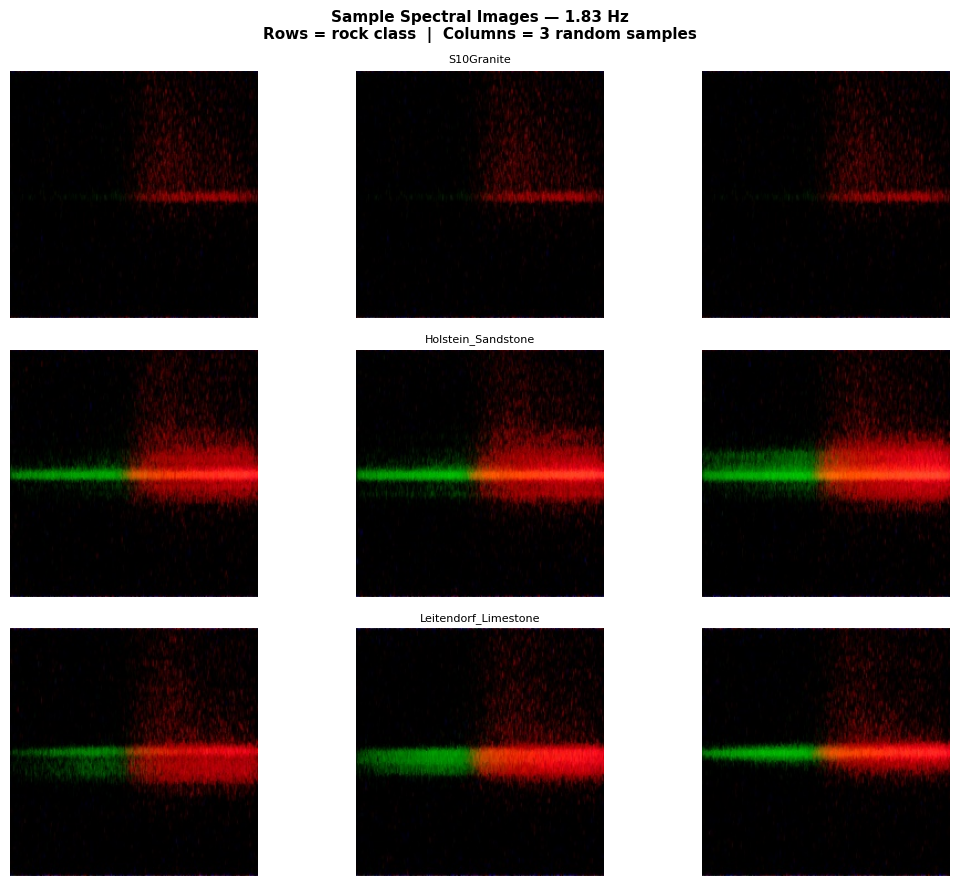

[SAVED] results_rock_classifier_combined/training/TR-00_sample_images__5-10Hz.png


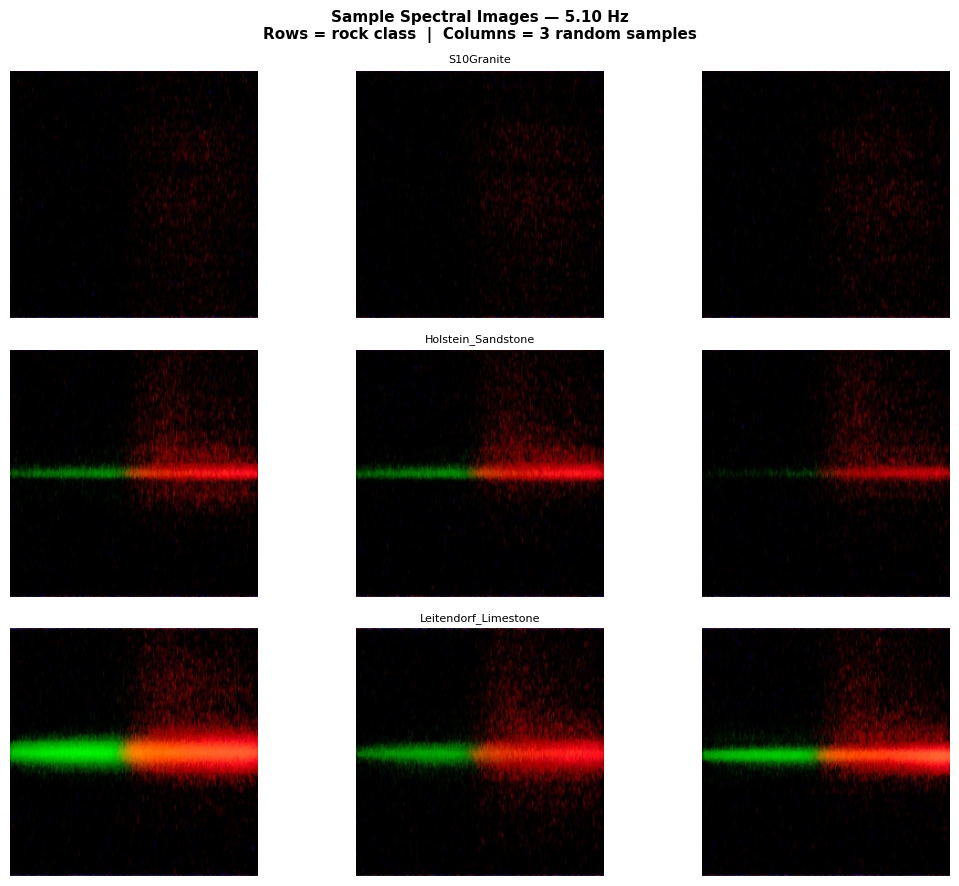

In [ ]:
# VISUALISE SAMPLE IMAGES (3 samples per rock class, both speeds)

for speed_tag, paths, _labels in [
    ('1.83 Hz', paths_183, labels_183),
    ('5.10 Hz', paths_510, labels_510)
]:
    fig, axes = plt.subplots(3, 3, figsize=(11, 9))
    fig.suptitle(
        f'Sample Spectral Images — {speed_tag}\n'
        'Rows = rock class  |  Columns = 3 random samples',
        fontsize=11, fontweight='bold')
    for i, rock_name in enumerate(class_names):
        rock_indices = [j for j, l in enumerate(_labels) if l == i][:3]
        for k, idx in enumerate(rock_indices):
            img = Image.open(paths[idx]).convert('RGB')
            axes[i][k].imshow(img)
            axes[i][k].set_title(rock_name if k == 1 else '', fontsize=8)
            axes[i][k].axis('off')
    plt.tight_layout()
    _tag = speed_tag.replace(' ', '').replace('.', '-')
    save_fig(fig, DIR_TRAIN,
        f'TR-00_sample_images__{_tag}.png',
        f'3 sample spectral images per rock class at {speed_tag}')
    plt.show()

In [ ]:
# TRAIN / TEST SPLIT

paths_train_183, paths_test_183, labels_train_183, labels_test_183 = \
    train_test_split(paths_183, labels_183,
                     test_size=TEST_SPLIT, stratify=labels_183, random_state=7)

paths_train_510, paths_test_510, labels_train_510, labels_test_510 = \
    train_test_split(paths_510, labels_510,
                     test_size=TEST_SPLIT, stratify=labels_510, random_state=7)

_at = 'STRONG' if USE_STRONG_AUG else 'standard'
train_ds_183 = SpectralImageDataset(paths_train_183, labels_train_183,
                                     transform=active_train_transform)
test_ds_183  = SpectralImageDataset(paths_test_183,  labels_test_183,
                                     transform=eval_transform)
train_ds_510 = SpectralImageDataset(paths_train_510, labels_train_510,
                                     transform=active_train_transform)
test_ds_510  = SpectralImageDataset(paths_test_510,  labels_test_510,
                                     transform=eval_transform)

print(f'Using [{_at}] augmentation')
print(f'1.83 Hz  train={len(paths_train_183)}  test={len(paths_test_183)}')
print(f'5.10 Hz  train={len(paths_train_510)}  test={len(paths_test_510)}')

Using [STRONG] augmentation
1.83 Hz  train=8455  test=3624
5.10 Hz  train=8533  test=3657


In [ ]:
# LR FINDER

def lr_finder(train_dataset, n_classes, lr_start=1e-7, lr_end=1.0,
              num_iter=200, arch='resnet18'):
    nw     = min(4, os.cpu_count() or 1)
    pin    = (device.type == 'cuda')
    loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                         num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    model     = build_model(n_classes, arch=arch).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_start)
    criterion = nn.CrossEntropyLoss()
    use_amp   = (device.type == 'cuda')
    scaler    = torch.amp.GradScaler('cuda') if use_amp else None

    mult      = (lr_end / lr_start) ** (1 / num_iter)
    lr        = lr_start
    best_loss = float('inf')
    avg_loss  = 0.0
    beta      = 0.98
    lrs, losses = [], []
    it = 0

    model.train()
    data_iter = iter(loader)
    while it < num_iter:
        try:
            Xb, yb = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); Xb, yb = next(data_iter)
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        if use_amp:
            with torch.amp.autocast('cuda'):
                out = model(Xb); loss = criterion(out, yb)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            out = model(Xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
        avg_loss = beta * avg_loss + (1 - beta) * loss.item()
        smoothed = avg_loss / (1 - beta ** (it + 1))
        if smoothed < best_loss: best_loss = smoothed
        if smoothed > 4 * best_loss:
            print(f'  Early stop at iter {it}'); break
        lrs.append(lr); losses.append(smoothed)
        lr *= mult
        for pg in optimizer.param_groups: pg['lr'] = lr
        it += 1

    del model, optimizer, criterion, loader
    if scaler: del scaler
    torch.cuda.empty_cache()

    fig_lr, ax_lr = plt.subplots(figsize=(8, 4))
    ax_lr.set_xscale('log')
    ax_lr.plot(lrs, losses, lw=1.5)
    ax_lr.set_xlabel('Learning rate (log scale)')
    ax_lr.set_ylabel('Smoothed loss')
    ax_lr.set_title(f'LR Finder — {arch}  |  '
                    f'Optimal LR = just before loss rises sharply')
    ax_lr.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig_lr, DIR_TRAIN,
        f'TR-LR_lr_finder.png',
        'LR finder: smoothed loss vs learning rate. '
        'Optimal LR is just before the loss rises sharply.')
    plt.show()
    return lrs, losses


# Uncomment to run LR finder:
# lrs, losses = lr_finder(train_ds_183, len(class_names), arch=ARCH)
print('LR finder defined. Uncomment the last line to run it.')

LR finder defined. Uncomment the last line to run it.


In [ ]:
# TRAINING FUNCTION
def train_and_save(train_ds, test_ds, model_save_path, speed_tag):
    """
    Train model, save best checkpoint.
    Returns history dict (or None if skipped), test paths, test labels.
    Skips if model_save_path already exists.
    """
    if os.path.exists(model_save_path):
        print(f'[SKIP] {os.path.basename(model_save_path)} exists. '
              f'Delete to retrain.')
        return None

    seed_everything(7)
    n_train = len(train_ds); n_test = len(test_ds)
    print(f'\nTraining [{speed_tag}]  '
          f'n_train={n_train}  n_test={n_test}  epochs={EPOCHS}')
    print(f'  arch={ARCH}  strong_aug={USE_STRONG_AUG}  '
          f'freeze_backbone={FREEZE_BACKBONE}')

    nw        = min(4, os.cpu_count() or 1)
    pin_mem   = (device.type == 'cuda')
    eff_batch = min(BATCH_SIZE, n_train)
    train_ldr = DataLoader(train_ds, eff_batch, shuffle=True,
                            num_workers=nw, pin_memory=pin_mem,
                            persistent_workers=(nw > 0))
    test_ldr  = DataLoader(test_ds,  eff_batch, shuffle=False,
                            num_workers=nw, pin_memory=pin_mem,
                            persistent_workers=(nw > 0))

    model     = build_model(len(class_names), arch=ARCH,
                             freeze_backbone=FREEZE_BACKBONE).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)
    warmup    = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=2)
    criterion = nn.CrossEntropyLoss()
    use_amp   = (device.type == 'cuda')
    scaler    = torch.amp.GradScaler('cuda') if use_amp else None

    train_accs, val_accs, train_losses, val_losses = [], [], [], []
    best_acc = -1.0

    for epoch in range(EPOCHS):
        model.train()
        ep_loss, ep_acc = [], []
        for Xb, yb in tqdm(train_ldr, desc=f'Ep {epoch+1}/{EPOCHS} train',
                            leave=False):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda'):
                    out = model(Xb); loss = criterion(out, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(optimizer); scaler.update()
            else:
                out = model(Xb); loss = criterion(out, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
            ep_loss.append(loss.item())
            ep_acc.append((out.argmax(1) == yb).float().mean().item())
        train_accs.append(float(np.mean(ep_acc)))
        train_losses.append(float(np.mean(ep_loss)))

        model.eval()
        vl, va = [], []
        all_preds, all_true = [], []
        with torch.no_grad():
            for Xb, yb in tqdm(test_ldr, desc=f'Ep {epoch+1}/{EPOCHS} val',
                                leave=False):
                Xb, yb = Xb.to(device), yb.to(device)
                out   = model(Xb); loss = criterion(out, yb)
                preds = out.argmax(1)
                vl.append(loss.item())
                va.append((preds == yb).float().mean().item())
                all_preds.extend(preds.cpu().tolist())
                all_true.extend(yb.cpu().tolist())
        val_acc = float(np.mean(va))
        val_accs.append(val_acc)
        val_losses.append(float(np.mean(vl)))

        if epoch < 2: warmup.step()
        else:         scheduler.step(val_acc)

        saved = ''
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            saved = ' [SAVED]'

        print(f'  Ep {epoch+1:>2}/{EPOCHS}  '
              f'train_loss={train_losses[-1]:.4f} acc={train_accs[-1]*100:.2f}%  '
              f'val_loss={val_losses[-1]:.4f} acc={val_acc*100:.2f}%{saved}')

    print(f'\n  Best val accuracy : {best_acc*100:.2f}%')
    print(f'  Saved to          : {model_save_path}')

    # Save class names alongside weights
    _tag = os.path.basename(model_save_path).replace('.pth', '')
    with open(os.path.join(RESULTS_DIR, f'{_tag}_class_names.json'), 'w') as jf:
        _json.dump(class_names, jf)

    del model, optimizer, criterion
    if scaler: del scaler
    torch.cuda.empty_cache()

    return {
        'train_accs':  train_accs,  'val_accs':  val_accs,
        'train_losses': train_losses, 'val_losses': val_losses,
        'best_acc': best_acc
    }

print('train_and_save() defined.')

train_and_save() defined.


In [23]:
# TRAIN 1.83 Hz MODEL
hist_183 = train_and_save(train_ds_183, test_ds_183, MODEL_183, '1.83 Hz')

[SKIP] rock_classifier_resnet18_combined_1-83Hz.pth exists. Delete to retrain.


In [24]:
# TRAIN 5.10 Hz MODEL
hist_510 = train_and_save(train_ds_510, test_ds_510, MODEL_510, '5.10 Hz')

[SKIP] rock_classifier_resnet18_combined_5-10Hz.pth exists. Delete to retrain.


In [25]:
# TR-01  Training history (loss + accuracy curves)
# What it shows: epoch-level train/val loss and accuracy for both belt speeds.
# Parallel curves with no divergence = no overfitting.
# Green dashed = best validation accuracy achieved (the checkpoint that was saved).

valid_hists = {k: v for k, v in [('1.83 Hz', hist_183), ('5.10 Hz', hist_510)]
               if v is not None}

if valid_hists:
    fig, axes = plt.subplots(2, len(valid_hists),
                              figsize=(8 * len(valid_hists), 10))
    if len(valid_hists) == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(
        'TR-01 | Training History -- Loss and Accuracy\n'
        f'arch={ARCH}  strong_aug={USE_STRONG_AUG}  '
        f'freeze_backbone={FREEZE_BACKBONE}  TEST_SPLIT={TEST_SPLIT}',
        fontsize=11, fontweight='bold')
    for col, (tag, h) in enumerate(valid_hists.items()):
        ep = range(1, len(h['train_accs']) + 1)
        # Accuracy subplot
        ax = axes[0][col]
        ax.plot(ep, np.array(h['train_accs'])*100, 'b-o', ms=4, label='Train acc')
        ax.plot(ep, np.array(h['val_accs'])*100,   'r-s', ms=4, label='Val acc')
        ax.axhline(h['best_acc']*100, color='green', ls='--', lw=1.2,
                   label=f'Best val: {h["best_acc"]*100:.2f}%')
        ax.set_title(f'{tag} — Accuracy', fontsize=11)
        ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
        # Loss subplot
        ax2 = axes[1][col]
        ax2.plot(ep, h['train_losses'], 'b-o', ms=4, label='Train loss')
        ax2.plot(ep, h['val_losses'],   'r-s', ms=4, label='Val loss')
        ax2.set_title(f'{tag} — Loss', fontsize=11)
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-entropy loss')
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    save_fig(fig, DIR_TRAIN,
        'TR-01_training_history__loss_and_accuracy__both_speeds.png',
        'Epoch-level training and validation loss + accuracy for both belt speeds. '
        f'Settings: strong_aug={USE_STRONG_AUG}, freeze_backbone={FREEZE_BACKBONE}.')
    plt.show()
else:
    print('Both models loaded from disk — training history not available.')

Both models loaded from disk — training history not available.


In [26]:
# LOAD SAVED MODEL WEIGHTS
def load_model(pth_path):
    if not os.path.exists(pth_path):
        raise FileNotFoundError(
            f'Model not found: {pth_path}\n'
            f'Run the training cells above first.')
    # Load with freeze_backbone=False so Grad-CAM can flow gradients
    model = build_model(len(class_names), arch=ARCH,
                         freeze_backbone=False).to(device)
    model.load_state_dict(
        torch.load(pth_path, map_location=device, weights_only=True))
    model.eval()
    return model

model_183 = load_model(MODEL_183)
model_510 = load_model(MODEL_510)
print(f'Loaded 1.83 Hz  <- {MODEL_183}')
print(f'Loaded 5.10 Hz  <- {MODEL_510}')

Loaded 1.83 Hz  <- results_rock_classifier_combined/rock_classifier_resnet18_combined_1-83Hz.pth
Loaded 5.10 Hz  <- results_rock_classifier_combined/rock_classifier_resnet18_combined_5-10Hz.pth


In [27]:
# COLLECT LOGITS + PREDICTIONS ON VALIDATION SET
def collect_logits(model, image_paths, labels):
    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    ds  = SpectralImageDataset(image_paths, labels, transform=eval_transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    all_logits, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for Xb, yb in ldr:
            logits = model(Xb.to(device)).cpu()
            all_logits.append(logits)
            all_labels.extend(yb.tolist())
            all_preds.extend(logits.argmax(1).tolist())
    return (torch.cat(all_logits, 0),
            np.array(all_labels), np.array(all_preds))

print('Collecting 1.83 Hz validation logits...')
logits_183, lte_183, pte_183 = collect_logits(
    model_183, paths_test_183, labels_test_183)
print(f'  n={len(lte_183)}  acc={np.mean(pte_183==lte_183)*100:.2f}%')

print('Collecting 5.10 Hz validation logits...')
logits_510, lte_510, pte_510 = collect_logits(
    model_510, paths_test_510, labels_test_510)
print(f'  n={len(lte_510)}  acc={np.mean(pte_510==lte_510)*100:.2f}%')

  n=3624  acc=99.53%
  n=3657  acc=99.56%


[SAVED] results_rock_classifier_combined/evaluation_known_rocks/EV-01_confusion_matrices__known_rocks__both_speeds.png


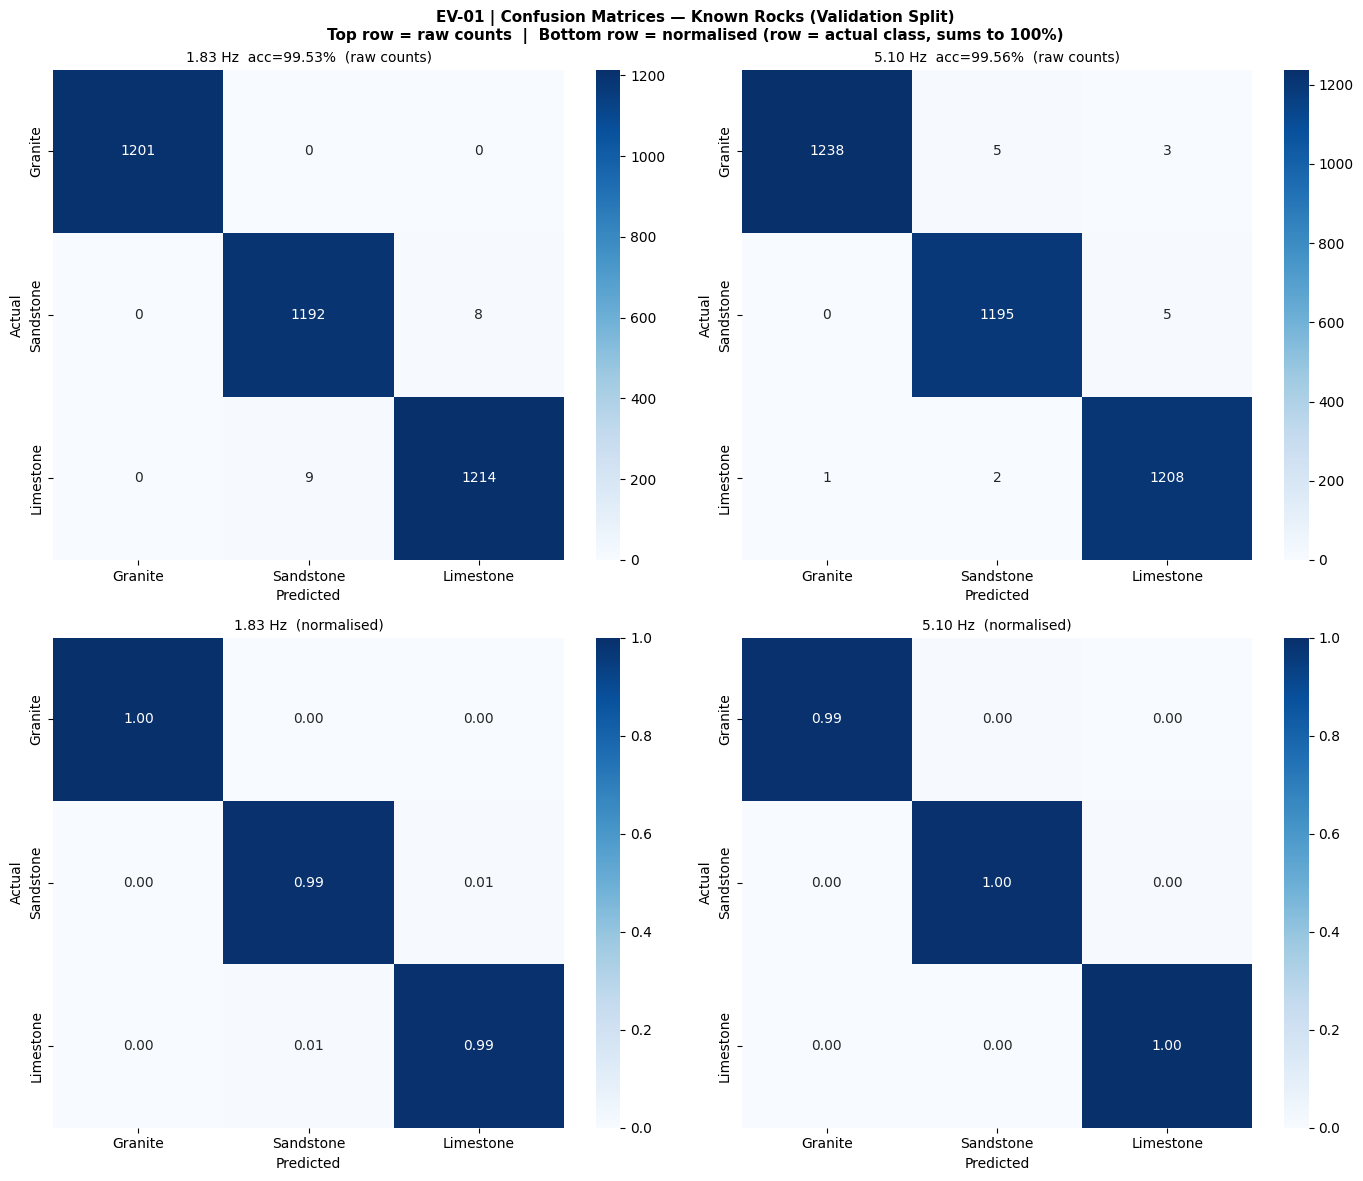

In [28]:
# EV-01  Confusion matrices on known rocks (normalised + raw counts)
# What it shows: how well the model classifies the 3 training rock types
# on the held-out validation set. Diagonal = correct, off-diagonal = errors.
# Shows both normalised % and raw image counts.

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    'EV-01 | Confusion Matrices — Known Rocks (Validation Split)\n'
    'Top row = raw counts  |  Bottom row = normalised (row = actual class, sums to 100%)',
    fontsize=11, fontweight='bold')

for col, (tag, preds, labels) in enumerate([
    ('1.83 Hz', pte_183, lte_183),
    ('5.10 Hz', pte_510, lte_510)
]):
    cm     = confusion_matrix(labels, preds)
    cm_n   = cm.astype(float)
    rs     = cm.sum(axis=1, keepdims=True)
    np.divide(cm_n, rs, out=cm_n, where=rs != 0)
    acc    = np.mean(preds == labels) * 100

    # Raw counts
    sns.heatmap(cm, ax=axes[0][col], annot=True, fmt='d', cmap='Blues',
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
    axes[0][col].set_title(f'{tag}  acc={acc:.2f}%  (raw counts)', fontsize=10)
    axes[0][col].set_ylabel('Actual'); axes[0][col].set_xlabel('Predicted')

    # Normalised
    sns.heatmap(cm_n, ax=axes[1][col], annot=True, fmt='.2f', cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
    axes[1][col].set_title(f'{tag}  (normalised)', fontsize=10)
    axes[1][col].set_ylabel('Actual'); axes[1][col].set_xlabel('Predicted')

plt.tight_layout()
save_fig(fig, DIR_EVAL,
    'EV-01_confusion_matrices__known_rocks__both_speeds.png',
    'Raw and normalised confusion matrices on the held-out validation split '
    'for both belt speeds. Shows classification accuracy per rock class.')
plt.show()

In [29]:
# EV-02  Classification reports (precision / recall / F1 per class)
rpts = {}
for tag, preds, labels in [
    ('1-83Hz', pte_183, lte_183),
    ('5-10Hz', pte_510, lte_510)
]:
    rpt_str = classification_report(
        labels, preds, target_names=class_names, digits=4)
    rpts[tag] = classification_report(
        labels, preds, target_names=class_names,
        output_dict=True, zero_division=0)
    print(f'=== {tag} ===\n{rpt_str}')
    path = os.path.join(DIR_EVAL,
        f'EV-02_classification_report__{tag}.txt')
    with open(path, 'w') as f:
        f.write(f'Settings: ARCH={ARCH} USE_STRONG_AUG={USE_STRONG_AUG} '
                f'FREEZE_BACKBONE={FREEZE_BACKBONE}\n\n')
        f.write(rpt_str)
    _saved_files.append((path,
        f'Classification report ({tag}) on known-rock validation split'))
    print(f'[SAVED] {path}\n')

=== 1-83Hz ===
                      precision    recall  f1-score   support

          S10Granite     1.0000    1.0000    1.0000      1201
  Holstein_Sandstone     0.9925    0.9933    0.9929      1200
Leitendorf_Limestone     0.9935    0.9926    0.9930      1223

            accuracy                         0.9953      3624
           macro avg     0.9953    0.9953    0.9953      3624
        weighted avg     0.9953    0.9953    0.9953      3624

[SAVED] results_rock_classifier_combined/evaluation_known_rocks/EV-02_classification_report__1-83Hz.txt

=== 5-10Hz ===
                      precision    recall  f1-score   support

          S10Granite     0.9992    0.9936    0.9964      1246
  Holstein_Sandstone     0.9942    0.9958    0.9950      1200
Leitendorf_Limestone     0.9934    0.9975    0.9955      1211

            accuracy                         0.9956      3657
           macro avg     0.9956    0.9956    0.9956      3657
        weighted avg     0.9956    0.9956    0.9956   

[SAVED] results_rock_classifier_combined/evaluation_known_rocks/EV-03_perclass_metrics__known_rocks__both_speeds.png


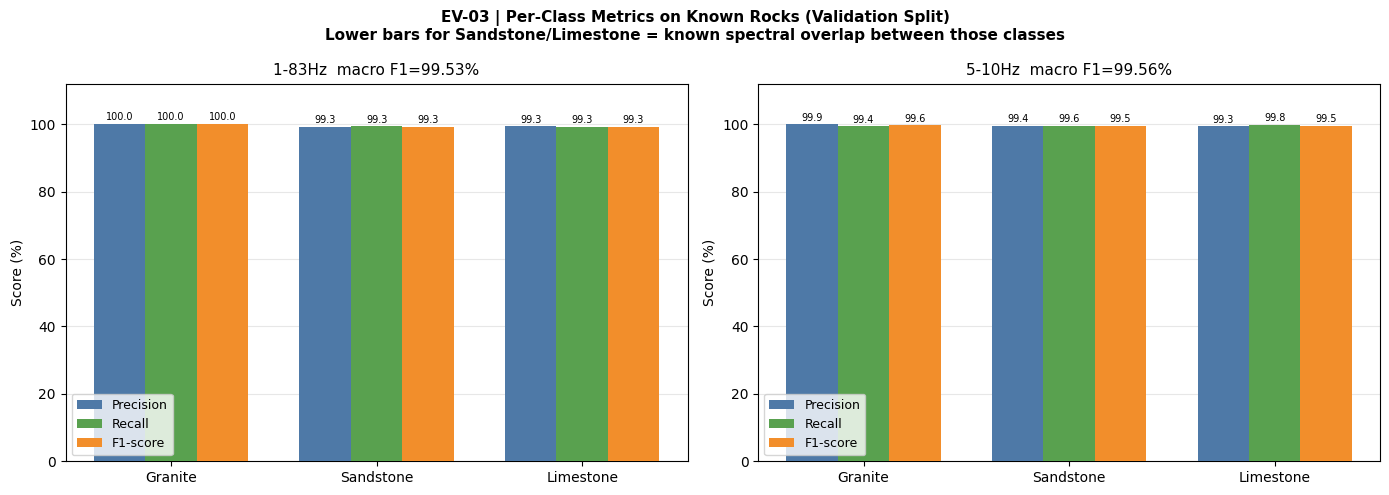

In [30]:
# EV-03  Per-class precision / recall / F1 bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'EV-03 | Per-Class Metrics on Known Rocks (Validation Split)\n'
    'Lower bars for Sandstone/Limestone = known spectral overlap between those classes',
    fontsize=11, fontweight='bold')
mc = ['#4e79a7', '#59a14f', '#f28e2b']
for ax, (tag, rpt) in zip(axes, rpts.items()):
    x = np.arange(len(class_names)); bw = 0.25
    for mi, (met, col) in enumerate(
            zip(['precision','recall','f1-score'], mc)):
        vals = [rpt[cls][met]*100 for cls in class_names]
        bars = ax.bar(x+(mi-1)*bw, vals, bw, color=col,
                       label=met.capitalize(), zorder=3)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, v+0.5,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    macro_f1 = rpt['macro avg']['f1-score']*100
    ax.set_title(f'{tag}  macro F1={macro_f1:.2f}%', fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES)
    ax.set_ylabel('Score (%)'); ax.set_ylim(0, 112)
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
save_fig(fig, DIR_EVAL,
    'EV-03_perclass_metrics__known_rocks__both_speeds.png',
    'Per-class precision, recall, and F1 score for both belt speeds '
    'on the held-out validation split.')
plt.show()

In [31]:
# EV-04  Test-Time Augmentation (TTA) evaluation
# What it shows: comparison of baseline accuracy vs TTA accuracy.
# TTA applies 5 augmented versions of each image and averages logits.
# Improvement = model benefits from ensemble-style prediction.

def evaluate_with_tta(model, image_paths, labels, speed_tag):
    baseline_preds, tta_preds = [], []
    true_labels_list = []

    for img_path, true_label in tqdm(
            zip(image_paths, labels), total=len(labels),
            desc=f'TTA {speed_tag}', leave=True):
        img = Image.open(img_path).convert('RGB')
        true_labels_list.append(true_label)

        # Baseline: single eval pass
        xb = eval_transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            logits_base = model(xb).cpu()
        baseline_preds.append(int(logits_base.argmax(1)))

        # TTA: average logits across all augmentation variants
        tta_logits = torch.zeros(1, len(class_names))
        for t in tta_transforms:
            xt = t(img).unsqueeze(0).to(device)
            with torch.no_grad():
                tta_logits += model(xt).cpu()
        tta_preds.append(int(tta_logits.argmax(1)))

    true_arr     = np.array(true_labels_list)
    baseline_arr = np.array(baseline_preds)
    tta_arr      = np.array(tta_preds)
    base_acc = np.mean(baseline_arr == true_arr) * 100
    tta_acc  = np.mean(tta_arr      == true_arr) * 100
    print(f'{speed_tag}  Baseline={base_acc:.2f}%  TTA={tta_acc:.2f}%  '
          f'delta={tta_acc-base_acc:+.2f}pp')
    return base_acc, tta_acc


print('Running TTA evaluation (may take a few minutes)...')
tta_results = {}
for tag, mdl, img_p, lbl in [
    ('1.83 Hz', model_183, paths_test_183, labels_test_183),
    ('5.10 Hz', model_510, paths_test_510, labels_test_510)
]:
    base_acc, tta_acc = evaluate_with_tta(mdl, img_p, lbl, tag)
    tta_results[tag] = {'baseline': base_acc, 'tta': tta_acc}

# Plot TTA comparison
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle(
    'EV-04 | Baseline vs TTA Accuracy on Known Rocks\n'
    f'TTA = {len(tta_transforms)} augmented versions averaged',
    fontsize=11, fontweight='bold')
tags = list(tta_results.keys()); x = np.arange(len(tags))
base_vals = [tta_results[t]['baseline'] for t in tags]
tta_vals  = [tta_results[t]['tta']      for t in tags]
b1 = ax.bar(x - 0.2, base_vals, 0.35, label='Baseline', color='#4e79a7')
b2 = ax.bar(x + 0.2, tta_vals,  0.35, label='TTA',      color='#76b7b2')
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                f'{b.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(tags)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(min(base_vals)-2, 102)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, DIR_EVAL,
    'EV-04_tta_vs_baseline__known_rocks__both_speeds.png',
    'Baseline vs TTA accuracy on held-out validation set. '
    f'TTA uses {len(tta_transforms)} augmented versions averaged per image.')
plt.show()

Running TTA evaluation (may take a few minutes)...


TTA 1.83 Hz:   1%|          | 45/3624 [00:00<00:25, 142.69it/s]


KeyboardInterrupt: 

In [ ]:
# TEMPERATURE SCALING + ENERGY-SCORE OOD THRESHOLDS

class TemperatureScaler(nn.Module):
    """Single-parameter post-hoc calibration (Guo et al. 2017)."""
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def calibrate(self, logits, labels):
        """Optimise T to minimise NLL on (logits, labels) — CPU tensors."""
        opt  = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        crit = nn.CrossEntropyLoss()
        def step():
            opt.zero_grad()
            loss = crit(logits / self.temperature.clamp(min=0.05), labels)
            loss.backward(); return loss
        opt.step(step)
        self.temperature.data = self.temperature.clamp(min=0.05)
        return self.temperature.item()

    def scale(self, logits):
        return logits / self.temperature.clamp(min=0.05)

    def energy(self, logits):
        """Energy score (higher -> more OOD).
        Formula: E(x) = -T * logsumexp(f(x)/T)"""
        return (
            -self.temperature.item()
            * torch.logsumexp(self.scale(logits), dim=1)
        ).detach().numpy()


scaler_183 = TemperatureScaler()
T_183 = scaler_183.calibrate(
    logits_183, torch.tensor(lte_183, dtype=torch.long))

scaler_510 = TemperatureScaler()
T_510 = scaler_510.calibrate(
    logits_510, torch.tensor(lte_510, dtype=torch.long))

print(f'Calibrated temperature — 1.83 Hz: T = {T_183:.4f}')
print(f'Calibrated temperature — 5.10 Hz: T = {T_510:.4f}')
print('(T > 1 = was overconfident; T < 1 = was underconfident)')

# Compute energy scores on validation (known-rock) data
energy_val_183 = scaler_183.energy(logits_183)
energy_val_510 = scaler_510.energy(logits_510)

# OOD threshold: (1 - OOD_FPR)*100th percentile
threshold_183 = float(np.percentile(energy_val_183, (1 - OOD_FPR) * 100))
threshold_510 = float(np.percentile(energy_val_510, (1 - OOD_FPR) * 100))

print(f'\nOOD threshold — 1.83 Hz: {threshold_183:.4f}')
print(f'OOD threshold — 5.10 Hz: {threshold_510:.4f}')
print(f'Targeting {OOD_FPR*100:.0f}% FPR on known rocks')
fpr_183 = np.mean(energy_val_183 > threshold_183) * 100
fpr_510 = np.mean(energy_val_510 > threshold_510) * 100
print(f'Actual FPR — 1.83 Hz: {fpr_183:.2f}%  5.10 Hz: {fpr_510:.2f}%')

In [ ]:
# OOD-01  Energy score distribution on known-rock validation data
# What it shows: histogram of energy scores for images the model knows well.
# The OOD threshold is set at the right tail of this distribution.
# New rock images with energy above this threshold are flagged as Unknown.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'OOD-01 | Energy Score Distribution on Known Rocks (Calibration Data)\n'
    'Higher energy = model is more uncertain\n'
    f'Red dashed = OOD threshold (right of line -> flagged as Unknown, '
    f'target FPR={OOD_FPR*100:.0f}%)',
    fontsize=11, fontweight='bold')
for ax, (tag, E, thr, T) in zip(axes, [
    ('1.83 Hz', energy_val_183, threshold_183, T_183),
    ('5.10 Hz', energy_val_510, threshold_510, T_510)
]):
    ax.hist(E, bins=40, color='#4e79a7', alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(thr, color='red', ls='--', lw=1.5,
               label=f'Threshold = {thr:.2f}')
    ax.set_title(f'{tag}  |  T={T:.3f}', fontsize=11)
    ax.set_xlabel('Energy score (higher = more OOD)')
    ax.set_ylabel('# images')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, DIR_OOD,
    'OOD-01_energy_distribution__known_rocks_calibration.png',
    'Energy score histogram on known-rock validation data with OOD threshold. '
    'New rocks with energy above threshold are flagged as Unknown.')
plt.show()

In [ ]:
# INFERENCE WITH OOD DETECTION
def run_inference_ood(model, scaler, threshold, image_paths):
    """Returns list of per-image result dicts."""
    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    ds  = UnlabelledDataset(image_paths, eval_transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    results = []
    with torch.no_grad():
        for Xb, fnames in ldr:
            logits   = model(Xb.to(device)).cpu()
            probs    = torch.softmax(scaler.scale(logits), dim=1).numpy()
            energies = scaler.energy(logits)
            for fname, prob, E in zip(fnames, probs, energies):
                pred_idx = int(np.argmax(prob))
                is_ood   = bool(E > threshold)
                results.append({
                    'filename'  : fname,
                    'pred_idx'  : pred_idx,
                    'pred_class': 'Unknown' if is_ood else class_names[pred_idx],
                    'confidence': float(np.max(prob)),
                    'energy'    : float(E),
                    'is_ood'    : is_ood,
                    'probs'     : prob.tolist(),
                })
    return results


test_root    = Path(TEST_DATA_ROOT)
test_folders = sorted([d for d in test_root.iterdir() if d.is_dir()])
folder_results = {}

print(f'Inferring on {len(test_folders)} new rock folders:')
for tf in test_folders:
    img_paths = sorted([str(f) for f in tf.iterdir()
                        if f.suffix.lower() in VALID_EXTENSIONS])
    if not img_paths:
        print(f'  [SKIP] {tf.name}'); continue

    use_510 = '5-10Hz' in tf.name
    mdl = model_510 if use_510 else model_183
    scl = scaler_510 if use_510 else scaler_183
    thr = threshold_510 if use_510 else threshold_183
    spd = '5.10 Hz' if use_510 else '1.83 Hz'

    print(f'  {tf.name}  [{spd}]  {len(img_paths)} imgs', end=' ... ', flush=True)
    res = run_inference_ood(mdl, scl, thr, img_paths)
    folder_results[tf.name] = res

    top = max(set(r['pred_class'] for r in res),
              key=lambda c: sum(1 for r in res if r['pred_class'] == c))
    print(f'top={top.split("_")[0]}  '
          f'conf={np.mean([r["confidence"] for r in res])*100:.1f}%  '
          f'OOD={sum(1 for r in res if r["is_ood"])}/{len(res)}')

folder_names = list(folder_results.keys())
n_folders    = len(folder_names)
print(f'\nDone. {n_folders} folders.')

In [ ]:
# Short display labels (strip repetitive prefixes for readability)
def shorten(fn):
    return (fn.replace('Limestone_', 'Lst_')
              .replace('Granite_3SamplesPhilipp_', 'Gran_Phil_')
              .replace('SandstoneNew', 'SstNew')
              .replace('Dunite-Ecologite_2Rocks_', 'Dun-Eco_')
              .replace('CalcsilicaContaminated_U9_U3_', 'CalcSil_'))

short_labels = [shorten(fn) for fn in folder_names]
print(short_labels)

In [ ]:
# INF-01  Prediction distribution per folder (includes Unknown category)
# What it shows:
#   Stacked bar per folder: % predicted as Granite / Sandstone / Limestone / Unknown.
#   Red Unknown segment = images flagged as OOD by the energy-score detector.
#   Expected class shown in italic below each bar.

display_classes = class_names + ['Unknown']
display_colors  = CLASS_COLORS + [OOD_COLOR]
display_short   = SHORT_NAMES + ['Unknown']

fig, ax = plt.subplots(figsize=(max(14, n_folders * 2), 8))
fig.suptitle(
    'INF-01 | Prediction Distribution per New Rock Folder (with Unknown / OOD)\n'
    'Colour = predicted class  |  Red = OOD (energy detector)\n'
    f'Number above = mean confidence  |  Italic below = expected class  |  '
    f'OOD FPR target = {OOD_FPR*100:.0f}%',
    fontsize=11, fontweight='bold')

x = np.arange(n_folders); bottom = np.zeros(n_folders)
for cls, color, short in zip(display_classes, display_colors, display_short):
    fracs = [sum(1 for r in folder_results[fn] if r['pred_class'] == cls)
             / len(folder_results[fn]) * 100
             for fn in folder_names]
    ax.bar(x, fracs, bottom=bottom, color=color, label=short, width=0.65)
    for xi, (frac, bot) in enumerate(zip(fracs, bottom)):
        if frac > 7:
            ax.text(xi, bot+frac/2, f'{frac:.0f}%', ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
    bottom += np.array(fracs)

for xi, fn in enumerate(folder_names):
    res   = folder_results[fn]
    conf  = np.mean([r['confidence'] for r in res]) * 100
    n_ood = sum(1 for r in res if r['is_ood'])
    ax.text(xi, 102, f'{conf:.0f}%\nconf', ha='center', va='bottom',
            fontsize=7, color='#333')
    if n_ood > 0:
        ax.text(xi, 111, f'\u26a0 {n_ood}', ha='center', va='bottom',
                fontsize=7, color='red')
    exp = EXPECTED_CLASS.get(fn, '?').split('_')[0]
    ax.text(xi, -9, f'exp:\n{exp}', ha='center', va='top',
            fontsize=6.5, color='navy', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% of images'); ax.set_ylim(-15, 122)
ax.set_yticks(range(0, 101, 20))
ax.legend(title='Predicted class', loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(100, color='black', lw=0.5); ax.axhline(0, color='black', lw=0.3)
plt.tight_layout()
save_fig(fig, DIR_INF,
    'INF-01_prediction_distribution__new_rocks__with_unknown.png',
    'Stacked bar chart: prediction distribution per new rock folder including '
    'Unknown (OOD) category. Expected class in italic below each bar.')
plt.show()

In [ ]:
# INF-02  Confidence & OOD flagging heatmap
# What it shows:
#   Left  = mean calibrated confidence (%).  High green = model is very sure.
#   Right = % of images flagged as Unknown. High red = model doesn't recognise the rock.

mean_confs = [np.mean([r['confidence'] for r in folder_results[fn]])*100
              for fn in folder_names]
pct_ood    = [sum(1 for r in folder_results[fn] if r['is_ood'])
              / len(folder_results[fn])*100
              for fn in folder_names]
mat = np.array([mean_confs, pct_ood]).T

fig, ax = plt.subplots(figsize=(5, max(5, n_folders * 0.65)))
fig.suptitle(
    'INF-02 | Calibrated Confidence & OOD Flagging per New Rock Folder\n'
    'Left = mean calibrated confidence (%)  |  '
    'Right = % images flagged as Unknown (OOD)\n'
    'High right column = model does not recognise this rock type',
    fontsize=10, fontweight='bold')
sns.heatmap(mat, ax=ax,
            xticklabels=['Mean\nConfidence (%)', 'OOD Flagged\n(Unknown) (%)'],
            yticklabels=short_labels,
            annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, linecolor='white', cbar_kws={'label': '%'})
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
save_fig(fig, DIR_INF,
    'INF-02_confidence_ood_heatmap__new_rocks.png',
    'Heatmap: mean calibrated confidence and % OOD-flagged images per new rock folder.')
plt.show()

In [ ]:
# INF-03  Confidence distribution histograms — classified vs OOD
# What it shows: per-folder histogram of calibrated max-softmax confidence.
# Blue = classified into a known class. Red = flagged as Unknown.
# Spike near 1.0 = confident. Spread = uncertain / OOD.

ncols = 3; nrows = int(np.ceil(n_folders / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows))
axes = axes.flatten()
fig.suptitle(
    'INF-03 | Confidence Distribution Histograms per New Rock Folder\n'
    'X = calibrated max-softmax probability  |  Y = # images\n'
    'Blue = classified  |  Red = flagged as Unknown (OOD)',
    fontsize=11, fontweight='bold')
for ax, fn in zip(axes, folder_names):
    res       = folder_results[fn]
    cls_confs = [r['confidence'] for r in res if not r['is_ood']]
    ood_confs = [r['confidence'] for r in res if r['is_ood']]
    lbl       = short_labels[folder_names.index(fn)]
    exp       = EXPECTED_CLASS.get(fn, '?').split('_')[0]
    top_cls   = max(set(r['pred_class'] for r in res),
                    key=lambda c: sum(1 for r in res if r['pred_class'] == c),
                    default='Unknown')
    col = CLASS_COLORS[class_names.index(top_cls)] \
          if top_cls in class_names else OOD_COLOR
    if cls_confs:
        ax.hist(cls_confs, bins=20, range=(0,1), color=col, alpha=0.8,
                label='Classified', edgecolor='white', lw=0.3)
    if ood_confs:
        ax.hist(ood_confs, bins=20, range=(0,1), color=OOD_COLOR, alpha=0.8,
                label='Unknown', edgecolor='white', lw=0.3)
    ax.set_title(
        f'{lbl}\ntop:{top_cls.split("_")[0]}  '
        f'conf:{np.mean([r["confidence"] for r in res])*100:.1f}%  '
        f'OOD:{len(ood_confs)}/{len(res)}  exp:{exp}',
        fontsize=7.5)
    ax.set_xlabel('Confidence', fontsize=8); ax.set_ylabel('# images', fontsize=8)
    ax.set_xlim(0, 1); ax.grid(True, alpha=0.3)
    if ood_confs: ax.legend(fontsize=7)
for ax in axes[n_folders:]: ax.set_visible(False)
plt.tight_layout()
save_fig(fig, DIR_INF,
    'INF-03_confidence_histograms__new_rocks.png',
    'Per-folder confidence histograms: classified vs OOD-flagged images.')
plt.show()

In [ ]:
# INF-04  Mean calibrated softmax probability vectors per folder
# What it shows: average probability assigned to each of the 3 classes
# over all images in each folder. One dominant colour = confident assignment.
# Even split = model is hedging (OOD-like behaviour).

mean_probs = np.array([
    np.mean([r['probs'] for r in folder_results[fn]], axis=0)
    for fn in folder_names])

fig, ax = plt.subplots(figsize=(max(12, n_folders * 2), 6))
fig.suptitle(
    'INF-04 | Mean Calibrated Softmax Probability per Class per New Folder\n'
    'One dominant colour = confident assignment  |  '
    'Even split = model is hedging (typical OOD behaviour)',
    fontsize=11, fontweight='bold')
x = np.arange(n_folders); bottom = np.zeros(n_folders)
for ci, (cls, color, short) in enumerate(
        zip(class_names, CLASS_COLORS, SHORT_NAMES)):
    vals = mean_probs[:, ci] * 100
    ax.bar(x, vals, bottom=bottom, color=color, label=short, width=0.65)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(xi, b+v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Mean calibrated probability (%)')
ax.set_ylim(0, 107); ax.set_yticks(range(0, 101, 20))
ax.legend(title='Trained class', loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3); ax.axhline(100, color='black', lw=0.5)
plt.tight_layout()
save_fig(fig, DIR_INF,
    'INF-04_mean_softmax_probabilities__new_rocks.png',
    'Mean calibrated softmax probability per trained class per new rock folder.')
plt.show()

In [ ]:
# INF-05  t-SNE feature-space projection
def extract_features(model, paths, transform, batch_size=64, max_samples=None):
    """Extract avgpool (512-d) features. Returns (array, used_paths)."""
    if max_samples and len(paths) > max_samples:
        idx   = np.random.choice(len(paths), max_samples, replace=False)
        paths = [paths[i] for i in sorted(idx)]
    feats = []
    hook  = model.avgpool.register_forward_hook(
        lambda m, i, o: feats.append(
            o.squeeze(-1).squeeze(-1).cpu().detach().numpy()))
    ds  = UnlabelledDataset(paths, transform)
    ldr = DataLoader(ds, batch_size, shuffle=False,
                      num_workers=min(4, os.cpu_count() or 1))
    model.eval()
    with torch.no_grad():
        for Xb, _ in ldr: _ = model(Xb.to(device))
    hook.remove()
    return np.vstack(feats), paths


# Collect training features (up to 400 per class)
print('Extracting training features...')
feat_chunks, label_chunks = [], []
for cls_idx, cls_name in enumerate(class_names):
    cls_paths = [p for p, l in zip(paths_183, labels_183) if l == cls_idx]
    f, _      = extract_features(model_183, cls_paths,
                                  eval_transform, max_samples=400)
    feat_chunks.append(f)
    label_chunks.extend([cls_name] * len(f))
    print(f'  {cls_name}: {len(f)} samples')

n_train_feats = len(label_chunks)

# Collect new rock features (up to 200 per folder)
print('\nExtracting new rock features...')
for fn in folder_names:
    img_paths = sorted([str(f) for f in Path(TEST_DATA_ROOT, fn).iterdir()
                        if f.suffix.lower() in VALID_EXTENSIONS])
    use_510   = '5-10Hz' in fn
    mdl       = model_510 if use_510 else model_183
    f, _      = extract_features(mdl, img_paths,
                                  eval_transform, max_samples=200)
    feat_chunks.append(f)
    label_chunks.extend([fn] * len(f))
    print(f'  {shorten(fn)}: {len(f)} samples')

X_all    = np.vstack(feat_chunks)
lbl_all  = np.array(label_chunks)
seed_everything(7)
print(f'\nRunning t-SNE on {X_all.shape[0]} samples × {X_all.shape[1]} features...')
tsne_2d = TSNE(n_components=2, perplexity=40,
               random_state=7, n_iter=1000).fit_transform(X_all)
print('t-SNE done.')

# ── Plot 
fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle(
    'INF-05 | t-SNE Feature-Space Projection — Training Rocks + New Rocks\n'
    'Large circles = training data  |  Markers = new rock folders\n'
    'Black edge = expected Unknown (OOD)  |  '
    'Clustering near training colour = model assigns those features to that class',
    fontsize=11, fontweight='bold')

# Training data
train_mask = (lbl_all == class_names[0]) | \
             (lbl_all == class_names[1]) | \
             (lbl_all == class_names[2])
for cls_name, color in zip(class_names, CLASS_COLORS):
    m = (lbl_all == cls_name)
    ax.scatter(tsne_2d[m, 0], tsne_2d[m, 1],
               c=color, s=18, alpha=0.35,
               label=cls_name.replace('_', ' '), zorder=2)

# New rocks
new_markers = ['P','X','*','D','v','^','<','>','h','H']
new_cmap    = plt.cm.tab10(np.linspace(0, 1, n_folders))
for fi, (fn, marker, color) in enumerate(
        zip(folder_names, new_markers, new_cmap)):
    m      = (lbl_all == fn)
    is_ood = EXPECTED_CLASS.get(fn) == 'Unknown'
    ax.scatter(tsne_2d[m, 0], tsne_2d[m, 1],
               c=[color], marker=marker, s=55, alpha=0.85, zorder=3,
               edgecolors='black' if is_ood else 'none', linewidths=0.8,
               label=shorten(fn))

ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.legend(title='Legend', fontsize=7, loc='best',
          framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
save_fig(fig, DIR_INF,
    'INF-05_tsne__training_and_new_rocks.png',
    't-SNE 2D projection of avgpool features for training rocks + new rock folders. '
    'Reveals why each new rock is classified as it is and whether features overlap.')
plt.show()

In [ ]:
# GRADCAM-01  One Grad-CAM per new rock folder
# What it shows: original image (left) vs Grad-CAM heatmap overlay (right).
# Warm (red/yellow) = the spectral regions that drove the prediction.
# Comparing correct vs incorrect folders reveals whether the model
# focuses on real spectral features or background artifacts.

imagenet_mean_t = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
imagenet_std_t  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

def tensor_to_rgb(t):
    return (t*imagenet_std_t + imagenet_mean_t).clamp(0,1).permute(1,2,0).numpy()


ncols = 2; nrows = int(np.ceil(n_folders / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*7, nrows*4))
axes = axes.flatten()
fig.suptitle(
    'GRADCAM-01 | Grad-CAM Heatmaps — One Sample per New Rock Folder\n'
    'Left = original spectral image  |  Right = Grad-CAM overlay\n'
    'Warm (red/yellow) = regions that drove the prediction  |  '
    '\u2705=Correct  \u274c=Incorrect  \u2753=Expected Unknown',
    fontsize=11, fontweight='bold')

for idx, fn in enumerate(folder_names):
    ax = axes[idx]
    img_paths = sorted([str(f) for f in Path(TEST_DATA_ROOT, fn).iterdir()
                        if f.suffix.lower() in VALID_EXTENSIONS])
    if not img_paths:
        ax.set_visible(False); continue

    sample_path = img_paths[len(img_paths) // 2]
    img_t = eval_transform(
        Image.open(sample_path).convert('RGB')).unsqueeze(0).to(device)

    use_510 = '5-10Hz' in fn
    mdl     = model_510 if use_510 else model_183

    cam_obj = GradCAM(mdl)
    cam, pred_idx = cam_obj.generate(img_t)
    cam_obj.remove()

    img_np  = tensor_to_rgb(img_t.squeeze(0).cpu())
    heatmap = plt.cm.jet(cam)[..., :3]
    overlay = np.clip(0.55*img_np + 0.45*heatmap, 0, 1)
    combined = np.concatenate([img_np, overlay], axis=1)

    res     = folder_results[fn]
    top_cls = max(set(r['pred_class'] for r in res),
                  key=lambda c: sum(1 for r in res if r['pred_class'] == c))
    exp_cls = EXPECTED_CLASS.get(fn, '?')

    if exp_cls == 'Unknown' and top_cls == 'Unknown':   verdict = '\u2705'
    elif exp_cls == 'Unknown' and top_cls != 'Unknown': verdict = '\u274c'
    elif top_cls == exp_cls:                             verdict = '\u2705'
    else:                                                verdict = '\u274c'

    ax.imshow(combined); ax.axis('off')
    ax.set_title(
        f'{shorten(fn)}\n'
        f'pred: {top_cls.split("_")[0]}  |  '
        f'exp: {exp_cls.split("_")[0]}  {verdict}',
        fontsize=8)

for ax in axes[n_folders:]: ax.set_visible(False)
plt.tight_layout()
save_fig(fig, DIR_CAM,
    'GRADCAM-01_gradcam_samples__all_new_folders.png',
    'Grad-CAM overlays for one representative image per new rock folder. '
    'Shows which spectral image regions drove each prediction.')
plt.show()

In [ ]:
# Verdict helper
def get_verdict(fn):
    res     = folder_results[fn]
    top_cls = max(set(r['pred_class'] for r in res),
                  key=lambda c: sum(1 for r in res if r['pred_class'] == c))
    exp_cls = EXPECTED_CLASS.get(fn, '?')
    if exp_cls == 'Unknown' and top_cls == 'Unknown': return '\u2705 Correctly Unknown', 'Correctly Unknown'
    if exp_cls == 'Unknown' and top_cls != 'Unknown': return '\u274c Missed OOD',        'Missed OOD'
    if exp_cls != 'Unknown' and top_cls == 'Unknown': return '\u26a0 False OOD',         'False OOD'
    if top_cls == exp_cls:                             return '\u2705 Correct',           'Correct'
    return '\u274c Incorrect', 'Incorrect'


rows = []
for fn in folder_names:
    res       = folder_results[fn]
    top_cls   = max(set(r['pred_class'] for r in res),
                    key=lambda c: sum(1 for r in res if r['pred_class'] == c))
    exp_cls   = EXPECTED_CLASS.get(fn, '?')
    n_ood     = sum(1 for r in res if r['is_ood'])
    mean_conf = np.mean([r['confidence'] for r in res]) * 100
    verdict, category = get_verdict(fn)
    rows.append([shorten(fn), exp_cls.split('_')[0],
                 top_cls.split('_')[0],
                 f'{n_ood}/{len(res)}',
                 f'{mean_conf:.1f}%', verdict, category])

print(f'\n{"="*100}')
print('FINAL COMPARISON: Expected vs Predicted')
print(f'{"="*100}')
print(f'{"Folder":<42} {"Expected":<12} {"Predicted":<12} {"OOD":>7} {"Conf":>7}  Result')
print('-'*100)
for r in rows:
    print(f'{r[0]:<42} {r[1]:<12} {r[2]:<12} {r[3]:>7} {r[4]:>7}  {r[5]}')
print('='*100)

In [ ]:
# CMP-01  Visual comparison table + outcome summary

categories = ['Correct', 'Correctly Unknown', 'Incorrect', 'Missed OOD', 'False OOD']
cat_colors  = ['#59a14f', '#76b7b2', '#e15759', '#ff9da7', '#f28e2b']
cat_counts  = {c: 0 for c in categories}
for r in rows: cat_counts[r[6]] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, n_folders*0.55+2)))
fig.suptitle(
    'CMP-01 | Final Comparison: Expected vs Predicted for Each New Rock Folder\n'
    'Left = per-folder results table  |  Right = outcome summary counts',
    fontsize=11, fontweight='bold')

# Left: colour-coded table
ax = axes[0]; ax.axis('off')
row_colors = []
for r in rows:
    row_colors.append({
        'Correct':            '#d9f0d3', 'Correctly Unknown': '#d9eef0',
        'Incorrect':          '#f7c6c7', 'Missed OOD':        '#f7c6c7',
        'False OOD':          '#fde8d0'
    }.get(r[6], 'white'))
tdata = [[r[0], r[1], r[2], r[3], r[4],
          r[5].replace('\u2705','OK').replace('\u274c','X').replace('\u26a0','!')]
         for r in rows]
tbl = ax.table(
    cellText=tdata,
    colLabels=['Folder','Expected','Predicted','OOD','Conf','Result'],
    cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
for i in range(len(tdata)):
    for j in range(6): tbl[i+1, j].set_facecolor(row_colors[i])
for j in range(6):
    tbl[0,j].set_facecolor('#d0d0d0'); tbl[0,j].set_text_props(fontweight='bold')
ax.set_title('Per-folder results', fontsize=10, fontweight='bold')

# Right: outcome summary
ax2 = axes[1]
valid_c  = [c for c in categories if cat_counts[c] > 0]
valid_co = [cat_colors[categories.index(c)] for c in valid_c]
valid_n  = [cat_counts[c] for c in valid_c]
bars = ax2.barh(valid_c, valid_n, color=valid_co, edgecolor='white')
for b, v in zip(bars, valid_n):
    ax2.text(v+0.05, b.get_y()+b.get_height()/2,
             str(v), va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Number of folders')
ax2.set_title('Outcome summary', fontsize=10, fontweight='bold')
ax2.set_xlim(0, max(valid_n)+1.5)
ax2.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, DIR_CMP,
    'CMP-01_expected_vs_predicted__table_and_summary.png',
    'Left: per-folder comparison table (expected vs predicted, OOD%, confidence, verdict). '
    'Right: outcome counts (Correct / Correctly Unknown / Incorrect / Missed OOD / False OOD).')
plt.show()

In [ ]:
# OOD-02  Energy score comparison: known rocks vs new rock folders
# What it shows: box plots of energy scores for each group.
# Known rocks should cluster below the threshold.
# OOD rocks (Dunite) should sit clearly above it.
# In-distribution new rocks (Rax Limestone) should be below.

# Collect energy scores for new folders
new_energies = {}
for fn in folder_names:
    img_paths = sorted([str(f) for f in Path(TEST_DATA_ROOT, fn).iterdir()
                        if f.suffix.lower() in VALID_EXTENSIONS])
    use_510 = '5-10Hz' in fn
    mdl = model_510 if use_510 else model_183
    scl = scaler_510 if use_510 else scaler_183
    nw  = min(4, os.cpu_count() or 1)
    ds  = UnlabelledDataset(img_paths, eval_transform)
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=False,
                      num_workers=nw, pin_memory=(device.type=='cuda'),
                      persistent_workers=(nw>0))
    energies = []
    with torch.no_grad():
        for Xb, _ in ldr:
            energies.extend(
                scl.energy(mdl(Xb.to(device)).cpu()).tolist())
    new_energies[fn] = energies

group_names = (['Known\n1.83Hz'] * len(energy_val_183) +
               ['Known\n5.10Hz'] * len(energy_val_510))
group_e     = list(energy_val_183) + list(energy_val_510)
for fn in folder_names:
    group_names.extend([shorten(fn)] * len(new_energies[fn]))
    group_e.extend(new_energies[fn])

all_group_names = (['Known\n1.83Hz', 'Known\n5.10Hz'] + short_labels)
all_group_data  = ({'Known\n1.83Hz': list(energy_val_183),
                    'Known\n5.10Hz': list(energy_val_510)})
all_group_data.update({shorten(fn): new_energies[fn] for fn in folder_names})

fig, ax = plt.subplots(figsize=(max(14, len(all_group_names)*1.4), 6))
fig.suptitle(
    'OOD-02 | Energy Score Comparison: Known Rocks vs New Rocks\n'
    'Each box = energy distribution for that group  |  Higher = more OOD\n'
    'Red dashed = OOD threshold  |  Boxes above line should be flagged Unknown',
    fontsize=11, fontweight='bold')
bp = ax.boxplot(
    [all_group_data[g] for g in all_group_names],
    positions=range(len(all_group_names)), patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    whiskerprops=dict(lw=1), capprops=dict(lw=1),
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
avg_thr = (threshold_183 + threshold_510) / 2
for i, (patch, gname) in enumerate(zip(bp['boxes'], all_group_names)):
    if 'Known' in gname:
        patch.set_facecolor('#59a14f'); patch.set_alpha(0.5)
    else:
        fn  = folder_names[i - 2]
        exp = EXPECTED_CLASS.get(fn, '?')
        patch.set_facecolor(OOD_COLOR if exp == 'Unknown' else '#4e79a7')
        patch.set_alpha(0.5)
ax.axhline(avg_thr, color='red', ls='--', lw=1.5,
           label=f'OOD threshold (avg) = {avg_thr:.2f}')
ax.set_xticks(range(len(all_group_names)))
ax.set_xticklabels(all_group_names, rotation=35, ha='right', fontsize=7.5)
ax.set_ylabel('Energy score')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
ax.set_title('Green = known rock  |  Blue = new in-distribution  '
             '|  Red = expected OOD', fontsize=9)
plt.tight_layout()
save_fig(fig, DIR_OOD,
    'OOD-02_energy_score_comparison__known_vs_new_rocks.png',
    'Box plots of energy scores: known rocks (calibration) vs each new folder. '
    'Groups above threshold should be flagged as Unknown.')
plt.show()

In [ ]:
# SAVE PER-IMAGE CSV
csv_img = os.path.join(RESULTS_DIR, 'predictions_new_rocks_all_images.csv')
with open(csv_img, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['folder','belt_speed','filename','predicted_class',
                'confidence','energy','is_ood',
                'prob_S10Granite','prob_Holstein_Sandstone',
                'prob_Leitendorf_Limestone'])
    for fn in folder_names:
        spd = '5.10 Hz' if '5-10Hz' in fn else '1.83 Hz'
        for r in folder_results[fn]:
            w.writerow([fn, spd, r['filename'], r['pred_class'],
                        round(r['confidence'],4), round(r['energy'],4),
                        r['is_ood'],
                        round(r['probs'][0],4), round(r['probs'][1],4),
                        round(r['probs'][2],4)])
_saved_files.append((csv_img,
    'Per-image: folder, speed, filename, predicted class, confidence, '
    'energy, OOD flag, full probability vector'))
print(f'[SAVED] {csv_img}')


# SAVE PER-FOLDER SUMMARY CSV
csv_fol = os.path.join(RESULTS_DIR, 'predictions_new_rocks_per_folder.csv')
with open(csv_fol, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['folder','expected_class','belt_speed','n_images',
                'top_predicted_class','mean_confidence_pct',
                'n_ood','pct_ood',
                'pct_Granite','pct_Sandstone','pct_Limestone','pct_Unknown',
                'mean_prob_Granite','mean_prob_Sandstone','mean_prob_Limestone',
                'mean_energy','verdict'])
    for fn in folder_names:
        res    = folder_results[fn]
        mp     = np.mean([r['probs'] for r in res], axis=0)
        cts    = {c: sum(1 for r in res if r['pred_class']==c)
                  for c in class_names+['Unknown']}
        top    = max(cts, key=cts.get)
        n_ood  = sum(1 for r in res if r['is_ood'])
        _, vrd = get_verdict(fn)
        spd    = '5.10 Hz' if '5-10Hz' in fn else '1.83 Hz'
        w.writerow([
            fn, EXPECTED_CLASS.get(fn,'?'), spd, len(res), top,
            round(np.mean([r['confidence'] for r in res])*100,2),
            n_ood, round(n_ood/len(res)*100,2),
            round(cts['S10Granite']          /len(res)*100,2),
            round(cts['Holstein_Sandstone']  /len(res)*100,2),
            round(cts['Leitendorf_Limestone']/len(res)*100,2),
            round(cts['Unknown']             /len(res)*100,2),
            round(mp[0]*100,2), round(mp[1]*100,2), round(mp[2]*100,2),
            round(np.mean([r['energy'] for r in res]),4), vrd
        ])
_saved_files.append((csv_fol,
    'Per-folder: expected class, predicted class, OOD stats, '
    'prediction distribution, mean probabilities, energy score, verdict'))
print(f'[SAVED] {csv_fol}')


# SAVE EVALUATION CSV
csv_eval = os.path.join(RESULTS_DIR, 'evaluation_known_rocks.csv')
with open(csv_eval, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['speed','class','precision','recall','f1_score','support'])
    for tag, rpt in rpts.items():
        for cls in class_names:
            w.writerow([tag, cls,
                        round(rpt[cls]['precision'],4),
                        round(rpt[cls]['recall'],4),
                        round(rpt[cls]['f1-score'],4),
                        int(rpt[cls]['support'])])
_saved_files.append((csv_eval,
    'Per-class precision/recall/F1/support on known-rock validation split'))
print(f'[SAVED] {csv_eval}')

In [ ]:
# WRITE RESULTS INDEX
index_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')

folder_map = {
    'training'               : 'PHASE 1 -- Train & Save',
    'evaluation_known_rocks' : 'PHASE 2 -- Evaluation on Known Rocks',
    'ood_calibration'        : 'PHASE 3 -- OOD Calibration',
    'inference_new_rocks'    : 'PHASE 4+5 -- Inference & t-SNE',
    'gradcam'                : 'PHASE 6 -- Grad-CAM',
    'comparison'             : 'PHASE 7 -- Final Comparison',
    '(root)'                 : 'ROOT FILES (CSVs + models + index)',
}
groups = {k: [] for k in folder_map}
for path, desc in _saved_files:
    placed = False
    for key in list(folder_map.keys())[:-1]:
        if key in path: groups[key].append((path,desc)); placed=True; break
    if not placed: groups['(root)'].append((path,desc))

with open(index_path,'w') as f:
    f.write('RESULTS INDEX -- rock_classifier_combined\n')
    f.write('='*80+'\n')
    f.write(f'ARCH={ARCH}  USE_STRONG_AUG={USE_STRONG_AUG}  '
            f'FREEZE_BACKBONE={FREEZE_BACKBONE}\n')
    f.write(f'EPOCHS={EPOCHS}  LR={LR}  WD={WEIGHT_DECAY}  '
            f'TEST_SPLIT={TEST_SPLIT}\n')
    f.write(f'OOD_FPR={OOD_FPR}\n')
    f.write(f'T_183={T_183:.4f}  T_510={T_510:.4f}\n')
    f.write(f'threshold_183={threshold_183:.4f}  '
            f'threshold_510={threshold_510:.4f}\n')
    f.write('='*80+'\n\n')
    for key, entries in groups.items():
        if not entries: continue
        f.write(folder_map[key]+'\n'+'-'*80+'\n')
        for path, desc in entries:
            f.write(f'  {os.path.basename(path)}\n')
            f.write(f'    {desc}\n\n')
        f.write('\n')

print(f'[SAVED] {index_path}')
print(f'\nTotal files saved: {len(_saved_files)}')
with open(index_path) as f:
    print('\n'+f.read())